# Red Bus Journey Data Analysis

In [1]:
#Insalling all dependent library
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow


In [2]:
#Mounting drive to get my data
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
#Load path where my dataset is
path = "/content/drive/MyDrive/RedBusAnalysis"

In [4]:
#Importing pandas
import pandas as pd

In [5]:
#Loading data set
train_data = pd.read_csv(path + "/train.csv")
transaction_data = pd.read_csv(path + "/transactions.csv")
test_data = pd.read_csv(path + "/test_8gqdJqH.csv")

In [6]:
train_data.head()

,doj,srcid,destid,final_seatcount
0,2023-03-01,45,46,2838.0
1,2023-03-01,46,45,2298.0
2,2023-03-01,45,47,2720.0
3,2023-03-01,47,45,2580.0
4,2023-03-01,46,9,4185.0


In [7]:
transaction_data.head()

,doj,doi,srcid,destid,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd
0,2023-03-01,2023-01-30,45,46,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,76.0,30
1,2023-03-01,2023-01-30,46,45,Tamil Nadu,Karnataka,Tier 1,Tier 1,8.0,70.0,30
2,2023-03-01,2023-01-30,45,47,Karnataka,Andhra Pradesh,Tier 1,Tier 1,4.0,142.0,30
3,2023-03-01,2023-01-30,47,45,Andhra Pradesh,Karnataka,Tier 1,Tier 1,0.0,68.0,30
4,2023-03-01,2023-01-30,46,9,Tamil Nadu,Tamil Nadu,Tier 1,Tier2,9.0,162.0,30


In [8]:
test_data.head()

,route_key,doj,srcid,destid
0,2025-02-11_46_45,2025-02-11,46,45
1,2025-01-20_17_23,2025-01-20,17,23
2,2025-01-08_02_14,2025-01-08,2,14
3,2025-01-08_08_47,2025-01-08,8,47
4,2025-01-08_09_46,2025-01-08,9,46


# Feature Extraction

In [9]:
#Filtering for prediction 15 days before journey
transaction_15 = transaction_data[transaction_data["dbd"] == 15]

In [10]:
transaction_15.head()

,doj,doi,srcid,destid,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd
1500,2023-03-01,2023-02-14,45,46,Karnataka,Tamil Nadu,Tier 1,Tier 1,16.0,480.0,15
1501,2023-03-01,2023-02-14,46,45,Tamil Nadu,Karnataka,Tier 1,Tier 1,34.0,352.0,15
1502,2023-03-01,2023-02-14,45,47,Karnataka,Andhra Pradesh,Tier 1,Tier 1,36.0,892.0,15
1503,2023-03-01,2023-02-14,47,45,Andhra Pradesh,Karnataka,Tier 1,Tier 1,18.0,1130.0,15
1504,2023-03-01,2023-02-14,46,9,Tamil Nadu,Tamil Nadu,Tier 1,Tier2,48.0,1023.0,15


In [11]:
#Creating unique route key to match later with test dataset
transaction_15["route_key"] = transaction_15["doj"] + "_" + transaction_15["srcid"].astype(str) + "_" + transaction_15["destid"].astype(str)

<ipython-input-11-1703587420>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_15["route_key"] = transaction_15["doj"] + "_" + transaction_15["srcid"].astype(str) + "_" + transaction_15["destid"].astype(str)


In [12]:
transaction_15.head()

,doj,doi,srcid,destid,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd,route_key
1500,2023-03-01,2023-02-14,45,46,Karnataka,Tamil Nadu,Tier 1,Tier 1,16.0,480.0,15,2023-03-01_45_46
1501,2023-03-01,2023-02-14,46,45,Tamil Nadu,Karnataka,Tier 1,Tier 1,34.0,352.0,15,2023-03-01_46_45
1502,2023-03-01,2023-02-14,45,47,Karnataka,Andhra Pradesh,Tier 1,Tier 1,36.0,892.0,15,2023-03-01_45_47
1503,2023-03-01,2023-02-14,47,45,Andhra Pradesh,Karnataka,Tier 1,Tier 1,18.0,1130.0,15,2023-03-01_47_45
1504,2023-03-01,2023-02-14,46,9,Tamil Nadu,Tamil Nadu,Tier 1,Tier2,48.0,1023.0,15,2023-03-01_46_9


In [40]:
#Selecting Relevant feature
features = transaction_15[["route_key", "cumsum_seatcount", "cumsum_searchcount", "srcid_region", "destid_region", "srcid_tier", "destid_tier"]]
features.head()

,route_key,cumsum_seatcount,cumsum_searchcount,srcid_region,destid_region,srcid_tier,destid_tier
1500,2023-03-01_45_46,16.0,480.0,Karnataka,Tamil Nadu,Tier 1,Tier 1
1501,2023-03-01_46_45,34.0,352.0,Tamil Nadu,Karnataka,Tier 1,Tier 1
1502,2023-03-01_45_47,36.0,892.0,Karnataka,Andhra Pradesh,Tier 1,Tier 1
1503,2023-03-01_47_45,18.0,1130.0,Andhra Pradesh,Karnataka,Tier 1,Tier 1
1504,2023-03-01_46_9,48.0,1023.0,Tamil Nadu,Tamil Nadu,Tier 1,Tier2


In [42]:
#Merge with train labels
train_data["route_key"] = train_data["doj"] + "_" + train_data["srcid"].astype(str) + "_" + train_data["destid"].astype(str)
#Drop if existing feature in train data to avoid collision during merge
cols_to_drop = ["cumsum_seatcount", "cumsum_searchcount",
                "srcid_region", "destid_region", "srcid_tier", "destid_tier"]

train_data = train_data.drop(columns=[col for col in cols_to_drop if col in train_data.columns])

train_data = train_data.merge(features, on="route_key", how="left")
#train_data.dropna(inplace=True)
train_data.head()

,doj,srcid,destid,final_seatcount,route_key,cumsum_seatcount,cumsum_searchcount,srcid_region,destid_region,srcid_tier,destid_tier
0,2023-03-01,45,46,2838.0,2023-03-01_45_46,16.0,480.0,Karnataka,Tamil Nadu,Tier 1,Tier 1
1,2023-03-01,46,45,2298.0,2023-03-01_46_45,34.0,352.0,Tamil Nadu,Karnataka,Tier 1,Tier 1
2,2023-03-01,45,47,2720.0,2023-03-01_45_47,36.0,892.0,Karnataka,Andhra Pradesh,Tier 1,Tier 1
3,2023-03-01,47,45,2580.0,2023-03-01_47_45,18.0,1130.0,Andhra Pradesh,Karnataka,Tier 1,Tier 1
4,2023-03-01,46,9,4185.0,2023-03-01_46_9,48.0,1023.0,Tamil Nadu,Tamil Nadu,Tier 1,Tier2


In [43]:
#Mergin with test set
duplicate_cols = [
    "cumsum_seatcount", "cumsum_searchcount",
    "srcid_region", "destid_region",
    "srcid_tier", "destid_tier"
]

# Drop them from test_data if they exist
test_data = test_data.drop(columns=[col for col in duplicate_cols if col in test_data.columns])
test_data = test_data.merge(features, on="route_key", how="left")
test_data['cumsum_seatcount'] = test_data['cumsum_seatcount'].fillna(0)
test_data['cumsum_searchcount'] = test_data['cumsum_searchcount'].fillna(0)
for col in ["srcid_region", "destid_region", "srcid_tier", "destid_tier"]:
    test_data[col] = test_data[col].fillna("Unknown")
test_data.head()

,route_key,doj,srcid,destid,cumsum_seatcount_x,cumsum_searchcount_x,srcid_region_x,destid_region_x,srcid_tier_x,destid_tier_x,...,srcid_region_y,destid_region_y,srcid_tier_y,destid_tier_y,cumsum_seatcount,cumsum_searchcount,srcid_region,destid_region,srcid_tier,destid_tier
0,2025-02-11_46_45,2025-02-11,46,45,38.0,1082.0,Tamil Nadu,Karnataka,Tier 1,Tier 1,...,Tamil Nadu,Karnataka,Tier 1,Tier 1,38.0,1082.0,Tamil Nadu,Karnataka,Tier 1,Tier 1
1,2025-01-20_17_23,2025-01-20,17,23,0.0,1175.0,East 1,East 1,Tier2,Tier 1,...,East 1,East 1,Tier2,Tier 1,0.0,1175.0,East 1,East 1,Tier2,Tier 1
2,2025-01-08_02_14,2025-01-08,2,14,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,Unknown,Unknown,Unknown,Unknown
3,2025-01-08_08_47,2025-01-08,8,47,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,Unknown,Unknown,Unknown,Unknown
4,2025-01-08_09_46,2025-01-08,9,46,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,Unknown,Unknown,Unknown,Unknown


# Data Preparation

In [44]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [45]:
# Encoding categorical features safely
categorical_features = ["srcid_region", "destid_region", "srcid_tier", "destid_tier"]
for col in categorical_features:
    le = LabelEncoder()

    # Combine train + test categories for fitting
    combined_values = pd.concat([train_data[col], test_data[col]], axis=0).astype(str)

    # Fit encoder on all possible values
    le.fit(combined_values)

    # Transform separately
    train_data[col] = le.transform(train_data[col].astype(str))
    test_data[col] = le.transform(test_data[col].astype(str))

In [46]:
#Select final features
features = ["cumsum_seatcount", "cumsum_searchcount"]
target = "final_seatcount"

In [47]:
X_train = train_data[features].values
Y_train = train_data[target].values
X_test = test_data[features].values

In [48]:
#Normalizing features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Model

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [50]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1) #Regression output layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
#Train model
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 3267477.5000 - root_mean_squared_error: 1785.2649 - val_loss: 1512780.5000 - val_root_mean_squared_error: 1229.9514
Epoch 2/50
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1080421.5000 - root_mean_squared_error: 1039.3580 - val_loss: 1392487.0000 - val_root_mean_squared_error: 1180.0369
Epoch 3/50
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1093437.7500 - root_mean_squared_error: 1045.4738 - val_loss: 1392965.5000 - val_root_mean_squared_error: 1180.2396
Epoch 4/50
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1075833.1250 - root_mean_squared_error: 1037.1719 - val_loss: 1354085.6250 - val_root_mean_squared_error: 1163.6519
Epoch 5/50
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1039480.3750 - root_mean_squared_error: 1019.2721 - val_loss: 1338552.6250 - val_root_mean_squared_error: 1156.9584
Epoch 6/50
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1047383.1875 - root_mean_squared_error: 1023.363

# Evaluation of Performance of Model

In [53]:
import matplotlib.pyplot as plt


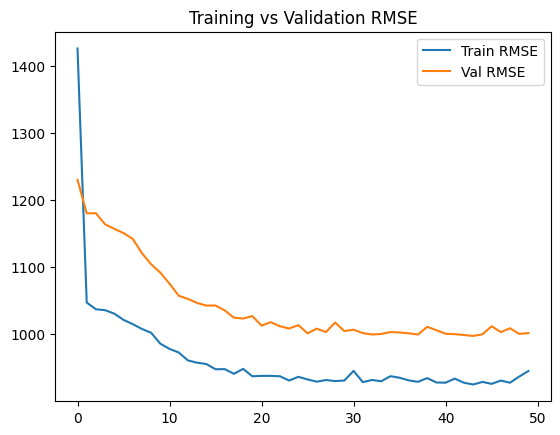

In [54]:
#plotting training history
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.legend()
plt.title('Training vs Validation RMSE')
plt.show()

# Predict Output

In [55]:
#Predict on test data
test_preds = model.predict(X_test).flatten()

185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [56]:
submission = test_data[["route_key"]].copy()
submission["final_seatcount"] = test_preds


In [57]:
submission.to_csv("submission_file.csv", index=False)

In [58]:
#Download submission file
from google.colab import files
files.download("submission_file.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
submission

,route_key,final_seatcount
0,2025-02-11_46_45,2105.684570
1,2025-01-20_17_23,1993.317505
2,2025-01-08_02_14,1142.892822
3,2025-01-08_08_47,1142.892822
4,2025-01-08_09_46,1142.892822
...,...,...
5895,2025-01-23_46_48,2854.969727
5896,2025-02-21_46_09,1142.892822
5897,2025-01-17_32_19,1458.763306
5898,2025-01-24_45_03,1142.892822
